In [1]:
!pip install requests beautifulsoup4 lxml

In [2]:
import requests
from bs4 import BeautifulSoup

url = "https://www.frontiersin.org/journals/sustainable-cities/articles/10.3389/frsc.2023.1308684/full"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
soup = BeautifulSoup(response.content, "lxml")

In [3]:
# Extract all paragraph text
paragraphs = soup.find_all("p")

article_text = " ".join([p.get_text() for p in paragraphs])

print(article_text[:2000])

Front. Sustain. Cities, 11 January 2024  Sec. Climate Change and Cities Volume 5 - 2023 | https://doi.org/10.3389/frsc.2023.1308684 Frontiers in Sustainable Cities  Part of a Research Topic Towards 2030: A Sustainable Cities Perspective on Achieving Sustainable Development Goal 13 – Climate Action Edited by Ravindra Khaiwal Post Graduate Institute of Medical Education and Research (PGIMER), India Reviewed by Teerachai Amnuaylojaroen University of Phayao, Thailand Akash Biswal Research Institute for Humanity and Nature, Japan Outline  Abstract 1 Introduction 2 Status of climate change in India 3 Climate change impacts 4 Climate change related extreme events in India 5 India's urban transformation and climate change 6 Vulnerable communities 7 Global climate change—Methodologies 8 Climate change mitigations status and strategies for India 9 Conclusion 10 Future directions for climate change studies in India Author contributions Funding Conflict of interest Publisher’s note References Figu

In [4]:
import re

article_text = article_text.lower()
article_text = re.sub(r'\s+', ' ', article_text)

print("Length of text:", len(article_text))

Length of text: 121499


In [6]:
for section in soup.find_all(['h2', 'h3', 'p']):
    print(section.get_text())

REVIEW article
Front. Sustain. Cities, 11 January 2024
 Sec. Climate Change and Cities
Volume 5 - 2023 | https://doi.org/10.3389/frsc.2023.1308684
Frontiers in Sustainable Cities 
Part of a Research Topic
Towards 2030: A Sustainable Cities Perspective on Achieving Sustainable Development Goal 13 – Climate Action
Editor & Reviewers
Edited by
Ravindra Khaiwal
Post Graduate Institute of Medical Education and Research (PGIMER), India
Reviewed by
Teerachai Amnuaylojaroen
University of Phayao, Thailand
Akash Biswal
Research Institute for Humanity and Nature, Japan
Outline 
Abstract
1 Introduction
2 Status of climate change in India
3 Climate change impacts
4 Climate change related extreme events in India
5 India's urban transformation and climate change
6 Vulnerable communities
7 Global climate change—Methodologies
8 Climate change mitigations status and strategies for India
9 Conclusion
10 Future directions for climate change studies in India
Author contributions
Funding
Conflict of interes

In [9]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import re

# Clean text
text = article_text.lower()
text = re.sub(r'[^a-z\s]', '', text)

tokens = word_tokenize(text)
stop_words = set(stopwords.words('english'))

tokens = [word for word in tokens if word not in stop_words and len(word) > 3]

# Create chunks (documents)
chunk_size = 100
docs = [tokens[i:i+chunk_size] for i in range(0, len(tokens), chunk_size)]

print("Number of documents:", len(docs))

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Number of documents: 97


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Topic Modeling — LDA

In [11]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 36.5 MB/s eta 0:00:00


In [12]:
from gensim import corpora
from gensim.models import LdaModel

# Dictionary & corpus
dictionary = corpora.Dictionary(docs)
corpus = [dictionary.doc2bow(doc) for doc in docs]

# Train LDA
lda_model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=5, passes=10)

print("\nLDA Topics:\n")
for idx, topic in lda_model.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")


LDA Topics:

Topic 0: 0.032*"climate" + 0.024*"change" + 0.014*"india" + 0.006*"cities" + 0.006*"urban"
Topic 1: 0.012*"climate" + 0.007*"urban" + 0.007*"forest" + 0.006*"change" + 0.005*"vegetation"
Topic 2: 0.017*"climate" + 0.015*"urban" + 0.014*"india" + 0.011*"change" + 0.007*"green"
Topic 3: 0.009*"climate" + 0.007*"pollution" + 0.006*"change" + 0.005*"health" + 0.005*"urban"
Topic 4: 0.028*"climate" + 0.021*"change" + 0.017*"india" + 0.007*"urban" + 0.007*"sustainable"


3. Topic Modeling — LSI

In [13]:
from gensim.models import LsiModel

lsi_model = LsiModel(corpus=corpus, id2word=dictionary, num_topics=5)

print("\nLSI Topics:\n")
for idx, topic in lsi_model.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")


LSI Topics:

Topic 0: 0.610*"climate" + 0.457*"change" + 0.305*"india" + 0.188*"urban" + 0.132*"cities"
Topic 1: -0.565*"urban" + 0.384*"india" + -0.262*"green" + -0.165*"infrastructure" + -0.117*"spaces"
Topic 2: 0.486*"india" + -0.330*"change" + -0.301*"climate" + 0.287*"urban" + 0.201*"emissions"
Topic 3: 0.305*"india" + 0.292*"cities" + -0.189*"forest" + 0.183*"delhi" + -0.168*"temperatures"
Topic 4: -0.237*"sustainable" + 0.207*"urban" + 0.205*"environ" + 0.201*"health" + -0.185*"climate"


 4. Hierarchical Clustering (Dendrogram)

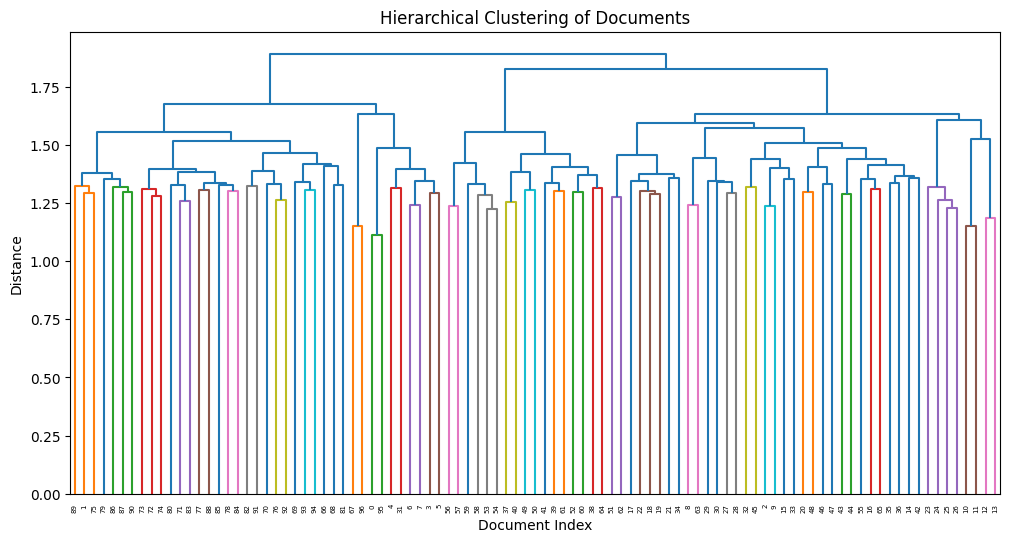

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Convert docs to strings
doc_strings = [" ".join(doc) for doc in docs]

# TF-IDF
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(doc_strings)

# Hierarchical clustering
Z = linkage(X.toarray(), method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering of Documents")
plt.xlabel("Document Index")
plt.ylabel("Distance")
plt.show()

5. LLM / Transformer Q&A

In [15]:
from transformers import pipeline

qa_pipeline = pipeline("question-answering", model="distilbert-base-cased-distilled-squad")

# Limit context
context = article_text[:2000]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [16]:
questions = [
    "What are the major impacts of climate change?",
    "How does climate change affect agriculture?",
    "What are the challenges for sustainable cities?",
    "What solutions are suggested?",
    "What sectors are most affected?"
]

print("\nQ&A Results:\n")
for q in questions:
    result = qa_pipeline(question=q, context=context)
    print(f"Q: {q}")
    print(f"A: {result['answer']}\n")


Q&A Results:

Q: What are the major impacts of climate change?
A: rapid escalation and ever-incr

Q: How does climate change affect agriculture?
A: global concern of the current century

Q: What are the challenges for sustainable cities?
A: air quality

Q: What solutions are suggested?
A: climate change and cities

Q: What sectors are most affected?
A: climate change and cities



Top 5 Keywords (TF-IDF)

In [17]:
import numpy as np

feature_names = vectorizer.get_feature_names_out()

# Average TF-IDF score
tfidf_scores = X.toarray().mean(axis=0)

top_indices = np.argsort(tfidf_scores)[-5:]
top_keywords = [feature_names[i] for i in top_indices]

print("Top 5 Keywords:", top_keywords)

Top 5 Keywords: ['cities', 'urban', 'india', 'change', 'climate']
